# Late Filers (Form NT) — the quant teardown 📝

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Second NT the kill signal?: Busted](https://img.shields.io/badge/Second_NT_the_kill_signal%3F-Busted-8b949e?style=flat-square)

**Claim.** An NT 10-K / NT 10-Q filing (Rule 12b-25 notification of late filing) is a sell signal: the filer underperforms the market in the weeks after the filing.

**Design.** One event per (CIK, filing date) of an exact-form NT from the EDGAR quarterly master index, 2004-01 → 2026-03; CIK→ticker via the SEC registry (currently-registered names only — the named **survivorship gate**); prices via yfinance (total-return); benchmark SPY. Short at the close of day +1 (exactly ONE execution lag), CAR = Σ daily (stock − SPY) over the next 60 trading days. Screens (stated, none silent): entry ≥ $1, no \|daily move\| > 100% in-window, ≥ 80% coverage. The **primary test is a calendar-time portfolio with a Newey-West HAC *t*** — NT events cluster around filing deadlines, so the naive cross-sectional *t* over-counts.

All real numbers live in the frozen dict `R` (mirror of [docs/results.md](../docs/results.md)); cells recompute them live from the cache.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from late_filers import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    EVENTS, PRICES = data.load_real()
    CARS = st.build_event_cars(EVENTS, PRICES)
else:
    EVENTS = PRICES = CARS = None
print("real NT cache present:", HAVE_REAL,
      "| usable events:", (0 if CARS is None else len(CARS)))

# frozen headline numbers (mirror of docs/results.md)
R = {'nt_total': 102505, 'ntk': 37502, 'ntq': 65003, 'in_window': 89497, 'mapped': 17199, 'mapped_pct': 19.2, 'events': 1993, 'tickers': 421, 'usable': 1180, 'use_ntk': 494, 'use_ntq': 686, 'use_repeat': 822, 'px_days': 5807, 'px_names': 422, 'px_start': '2003-06-02', 'px_end': '2026-06-30', 'as_of': '2026-06-30', 'fp_events': '82ef3cc79145', 'fp_spy': '860d1267b8a2', 'reaction_bps': -33.0, 't_reaction': -0.99, 'car_bps': -105.7, 't_naive': -0.71, 'ct_bps_day': 3.39, 'ct_hac_t': 0.83, 'ct_ann': 8.9, 'ct_days': 5623, 'ct_avg_names': 12.6, 'pseudo_bps': 81.9, 'pseudo_n': 714, 'welch_vs_pseudo': -0.77, 'placebo_bps': 381.2, 'placebo_std': 147.1, 'placebo_seeds': 25, 'ntk_car': -205.1, 'ntk_t': -0.89, 'ntk_n': 494, 'ntk_hac': 0.52, 'ntq_car': -34.2, 'ntq_t': -0.17, 'ntq_n': 686, 'ntq_hac': 0.66, 'rep_car': 58.0, 'rep_n': 822, 'rep_hac': 1.18, 'fst_car': -481.7, 'fst_n': 358, 'fst_hac': -0.59, 'rep_minus_fst': 539.7, 'welch_rep': 1.85, 'robust': [(20, -146.4, -0.96), (40, -5.5, 0.06), (60, -105.7, 0.83)], 'costs': [(10.0, 3.0, 14.3), (10.0, 10.0, -152.4), (20.0, 3.0, -5.7), (20.0, 10.0, -172.4)], 'syn': [(0.0, 90.6, 0.94, 0.55), (-20.0, -1152.3, -11.93, -10.42)]}


real NT cache present: True | usable events: 1180


## 1 — Panel

- EDGAR NT index 2002→2026: **102,505** filings (**37,502** NT 10-K / **65,003** NT 10-Q).
- Event window 2004-01→2026-03: **89,497** filings, of which only **17,199 (19.2%)** map to a currently-registered ticker — the survivorship gate. Delisted offenders (the worst outcomes) are structurally excluded, so every drift number below is biased **toward zero**.
- Seeded caps (500 tickers / 2,000 events) → 1,993 events on 421 tickers; **1,180** usable after the stated screens (494 NT 10-K / 686 NT 10-Q; 822 repeat offenders).
- Prices: 5,807 days × 422 names, 2003-06-02 → 2026-06-30, as-of **2026-06-30**. Fingerprints: events `82ef3cc79145`, SPY `860d1267b8a2`.

In [2]:
if HAVE_REAL:
    cs = st.cross_sectional_stats(CARS)
    ct = st.calendar_time_portfolio(CARS, PRICES)
    print(f"usable events {len(CARS):,} | mean CAR[+1,+60td] {cs['car_bps']:+.1f} bps "
          f"(naive t {cs['t_naive']:+.2f}) | reaction {cs['reaction_bps']:+.1f} bps")
    print(f"calendar-time: {ct['mean_bps_day']:+.2f} bps/day vs SPY, HAC t = {ct['hac_t']:+.2f} "
          f"({ct['ann_pct']:+.1f}%/yr over {ct['n_days']:,} active days)")
else:
    print('frozen:', R['car_bps'], 'bps, HAC t', R['ct_hac_t'])

usable events 1,180 | mean CAR[+1,+60td] -105.7 bps (naive t -0.71) | reaction -33.0 bps
calendar-time: +3.39 bps/day vs SPY, HAC t = +0.83 (+8.9%/yr over 5,623 active days)


## 2 — The drift and the primary test

| quantity | value |
|---|--:|
| announcement reaction (day 0 → entry close, NOT tradable) | **-33.0 bps** (naive t -0.99) |
| mean CAR[+1, +60td] vs SPY | **-105.7 bps** |
| naive cross-sectional *t* (over-counted; reported, not relied on) | -0.71 |
| **calendar-time portfolio (PRIMARY)** | **+3.39 bps/day**, **HAC *t* = +0.83** (+8.9%/yr, avg 12.6 names/day) |

> 💡 **In plain words** — the per-event average is a ~1% dip, but the honest test (one that doesn't double-count the heavily overlapping deadline-clustered windows) reads +0.83 — pure noise. The sign even flips between the two aggregations, which is exactly what "nothing here" looks like on a wide-tailed small-cap panel.

## 3 — Controls: same firms earlier + random dates

| control | mean CAR | test |
|---|--:|--|
| real NT events (n=1,180) | **-105.7 bps** | — |
| same firms, 252 td earlier (n=714) | +81.9 bps | Welch *t* vs events = **-0.77** |
| random dates × 25 seeds | +381.2 bps (σ across seeds 147.1) | — |

> 💡 **In plain words** — the surviving names drift *up* on random days (survival bias in person). NT windows sit ~490 bps below that personal baseline — the right sign for the claim, but Welch *t* = −0.77 is noise. We report the direction; we don't grade on it.

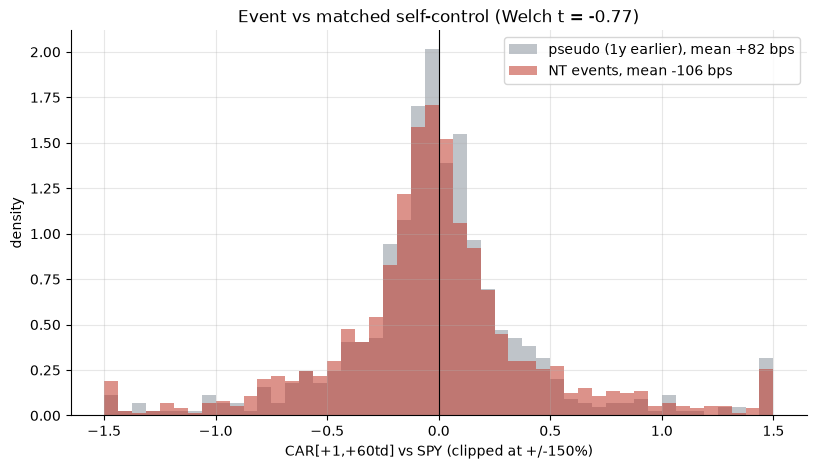

In [3]:
if HAVE_REAL:
    pse = st.pseudo_events(EVENTS, PRICES)
    pcars = st.build_event_cars(pse, PRICES)
    wt, m_ev, m_ps = st.welch_t(CARS['car'].to_numpy(), pcars['car'].to_numpy())
    fig, ax = plt.subplots()
    bins = np.linspace(-1.5, 1.5, 49)
    ax.hist(np.clip(pcars['car'], -1.5, 1.5), bins=bins, alpha=.55, color=GREY,
            density=True, label=f'pseudo (1y earlier), mean {m_ps*1e4:+.0f} bps')
    ax.hist(np.clip(CARS['car'], -1.5, 1.5), bins=bins, alpha=.55, color=RED,
            density=True, label=f'NT events, mean {m_ev*1e4:+.0f} bps')
    ax.axvline(0, color='k', lw=.8)
    ax.set_xlabel('CAR[+1,+60td] vs SPY (clipped at +/-150%)'); ax.set_ylabel('density')
    ax.legend(); ax.set_title(f'Event vs matched self-control (Welch t = {wt:+.2f})')
    plt.show()
else:
    print('frozen: Welch t vs pseudo =', R['welch_vs_pseudo'])

## 4 — Splits & robustness

| slice | CAR (bps) | n | cal-time HAC *t* |
|---|--:|--:|--:|
| NT 10-K (annual miss) | -205.1 | 494 | +0.52 |
| NT 10-Q (quarterly miss) | -34.2 | 686 | +0.66 |

| window | CAR (bps) | cal-time HAC *t* |
|---|--:|--:|
| 20 td | -146.4 | -0.96 |
| 40 td | -5.5 | +0.06 |
| 60 td | -105.7 | +0.83 |

> 💡 **In plain words** — no slice and no horizon clears (or approaches) the *t* ≥ 2 bar. The 10-K miss looks heavier than the 10-Q miss in the point estimate, as the literature would predict, but neither certifies.

## 5 — Third axis: is the SECOND consecutive NT the kill signal?

| group | CAR (bps) | n | cal-time HAC *t* |
|---|--:|--:|--:|
| repeat offenders (prior NT ≤ 15 months) | **+58.0** | 822 | +1.18 |
| first offenses | **-481.7** | 358 | -0.59 |

Difference (repeat − first): **+539.7 bps**, Welch *t* = **+1.85** — sub-2 AND the **wrong sign** for the folklore: chronic lateness is priced as routine, first confessions carry what little drift there is. **Busted.**

## 6 — Tradability: the short pays twice, then pays the borrow

Gross short capture = +105.7 bps per event (60-td hold), *granting* the uncertified drift. Net after 2 × one-way cost + borrow held 60/252 of a year:

| one-way cost | borrow %/yr | net (bps/event) |
|--:|--:|--:|
| 10 bps | 3% | **+14.3** |
| 10 bps | 10% | **-152.4** |
| 20 bps | 3% | **-5.7** |
| 20 bps | 10% | **-172.4** |

> 💡 **In plain words** — +14 bps per event in the friendliest case (large-cap costs on small-cap shorts — already a fiction) and negative everywhere realistic. Survivorship cuts both ways here: it understates the *signal* (delisted disasters missing) and overstates the *accessibility* (those same names had no borrow). **Mirage.**

## 7 — Synthetic positive control (machinery proof only)

Deterministic beta-1 panel with planted NT-style events: with **0** planted drift the machinery must stay silent; with **−20 bps/day** planted over the measured window it must light up.

| planted drift | CAR (bps) | naive *t* | cal-time HAC *t* |
|--:|--:|--:|--:|
| +0 bps/d | +90.6 | +0.94 | +0.55 |
| -20 bps/d | -1152.3 | -11.93 | -10.42 |

The real-tape non-result is not a power failure of the harness. *(Never cited in support of a Signal stamp.)*

In [4]:
for edge in (0.0, -20.0):
    ev, px = data.synthetic_world(edge_bps_day=edge, seed=630)
    cars = st.build_event_cars(ev, px)
    cs2 = st.cross_sectional_stats(cars)
    ct2 = st.calendar_time_portfolio(cars, px)
    print(f"planted {edge:+6.1f} bps/d: CAR {cs2['car_bps']:+8.1f} bps  "
          f"naive t {cs2['t_naive']:+5.2f}  cal-time HAC t {ct2['hac_t']:+6.2f}")

planted   +0.0 bps/d: CAR    +90.6 bps  naive t +0.94  cal-time HAC t  +0.55


planted  -20.0 bps/d: CAR  -1152.3 bps  naive t -11.93  cal-time HAC t -10.42


## Verdict

- **Signal — WEAK.** Literature (Griffin 2003; Bartov et al.; Duarte-Silva et al. 2013) says real; this tape can't certify it: calendar-time HAC *t* = +0.83, self-control Welch *t* = -0.77, no slice near 2. The panel is severely survivor-biased (19.2% ticker coverage; the delisting disasters are structurally excluded), biasing the drift toward zero — "literature says real; this survivors-only tape alone can't certify it".
- **Tradability — MIRAGE.** Net short edge ≈ +14 bps/event at best, negative at realistic small-cap borrow; the names that would carry the edge are hard-to-borrow or delisted.
- **Second NT the kill signal? — BUSTED.** Repeat − first = +539.7 bps (Welch *t* = +1.85): wrong sign for the folklore — the first confession carries whatever information exists.

*Research & education, not investment advice.*